In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


plt.figure(figsize=(10,5))
sns.set_style("whitegrid")

amazon_india_2015_2025 = pd.read_csv("D:\\Code\\Project\\Amazon\\data\\cleaned\\amazon_india_cleaned_data.csv")
amazon_india_2015_2025['order_date'] = pd.to_datetime(amazon_india_2015_2025['order_date'])

<Figure size 1000x500 with 0 Axes>

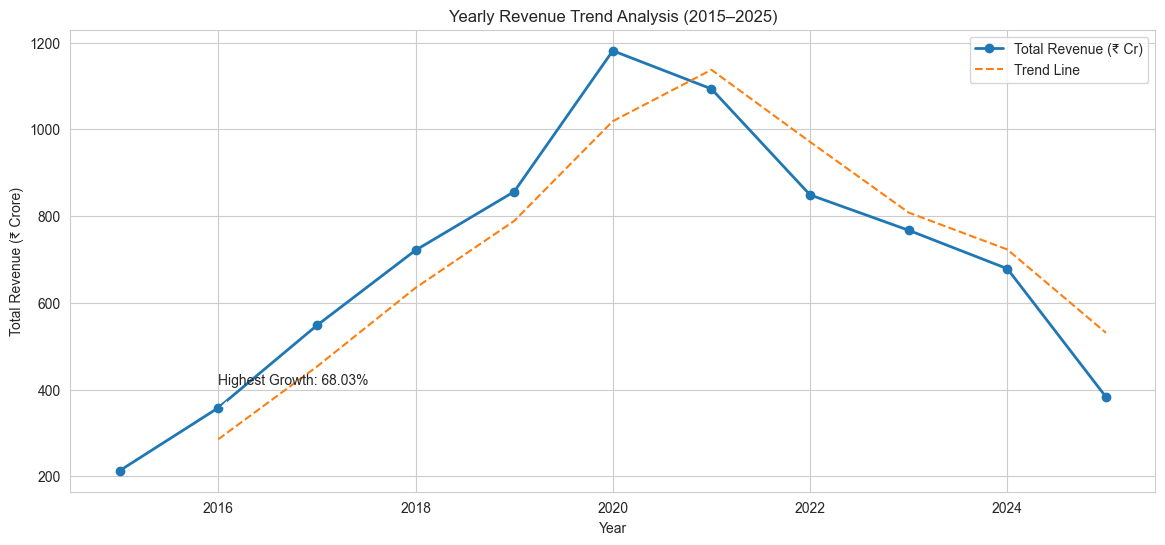

,order_year,revenue_cr,yoy_growth_pct,trend
0,2015,213.05,NaN,NaN
1,2016,357.99,68.03,285.520
2,2017,548.00,53.08,452.995
3,2018,721.33,31.63,634.665
4,2019,856.35,18.72,788.840
5,2020,1181.36,37.95,1018.855
6,2021,1093.41,-7.44,1137.385
7,2022,848.97,-22.36,971.190
8,2023,767.38,-9.61,808.175
9,2024,678.82,-11.54,723.100


In [12]:
import matplotlib.pyplot as plt

# 1️⃣ Aggregate yearly revenue
yearly_revenue = (
    amazon_india_2015_2025
    .groupby('order_year')['final_amount_inr']
    .sum()
    .reset_index()
    .sort_values('order_year')
)

# Convert to Crores
yearly_revenue['revenue_cr'] = (yearly_revenue['final_amount_inr'] / 1e7).round(2)

# 2️⃣ Calculate YoY growth %
yearly_revenue['yoy_growth_pct'] = (
    yearly_revenue['revenue_cr']
    .pct_change() * 100
).round(2)

# 3️⃣ Trend line (rolling mean)
yearly_revenue['trend'] = (
    yearly_revenue['revenue_cr']
    .rolling(window=2)
    .mean()
)

# 4️⃣ Identify highest growth year
max_growth = yearly_revenue.loc[
    yearly_revenue['yoy_growth_pct'].idxmax()
]

# 5️⃣ Plot
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_revenue['order_year'],
    yearly_revenue['revenue_cr'],
    marker='o',
    linewidth=2,
    label='Total Revenue (₹ Cr)'
)

plt.plot(
    yearly_revenue['order_year'],
    yearly_revenue['trend'],
    linestyle='--',
    label='Trend Line'
)

# Annotation
plt.annotate(
    f"Highest Growth: {max_growth['yoy_growth_pct']}%",
    xy=(max_growth['order_year'], max_growth['revenue_cr']),
    xytext=(max_growth['order_year'], max_growth['revenue_cr'] * 1.15),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Yearly Revenue Trend Analysis (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Total Revenue (₹ Crore)')
plt.legend()
plt.grid(True)

plt.show()

# 6️⃣ Final table output
yearly_revenue[['order_year', 'revenue_cr', 'yoy_growth_pct', 'trend']]

2.Seasonal Sales Trend Analysis Using Monthly Heatmaps

Peak selling month per year:
order_year
2015    Dec
2016    Dec
2017    Dec
2018    Dec
2019    Dec
2020    Dec
2021    Dec
2022    Dec
2023    Dec
2024    Dec
2025    Dec

Overall peak month (all years combined): Dec


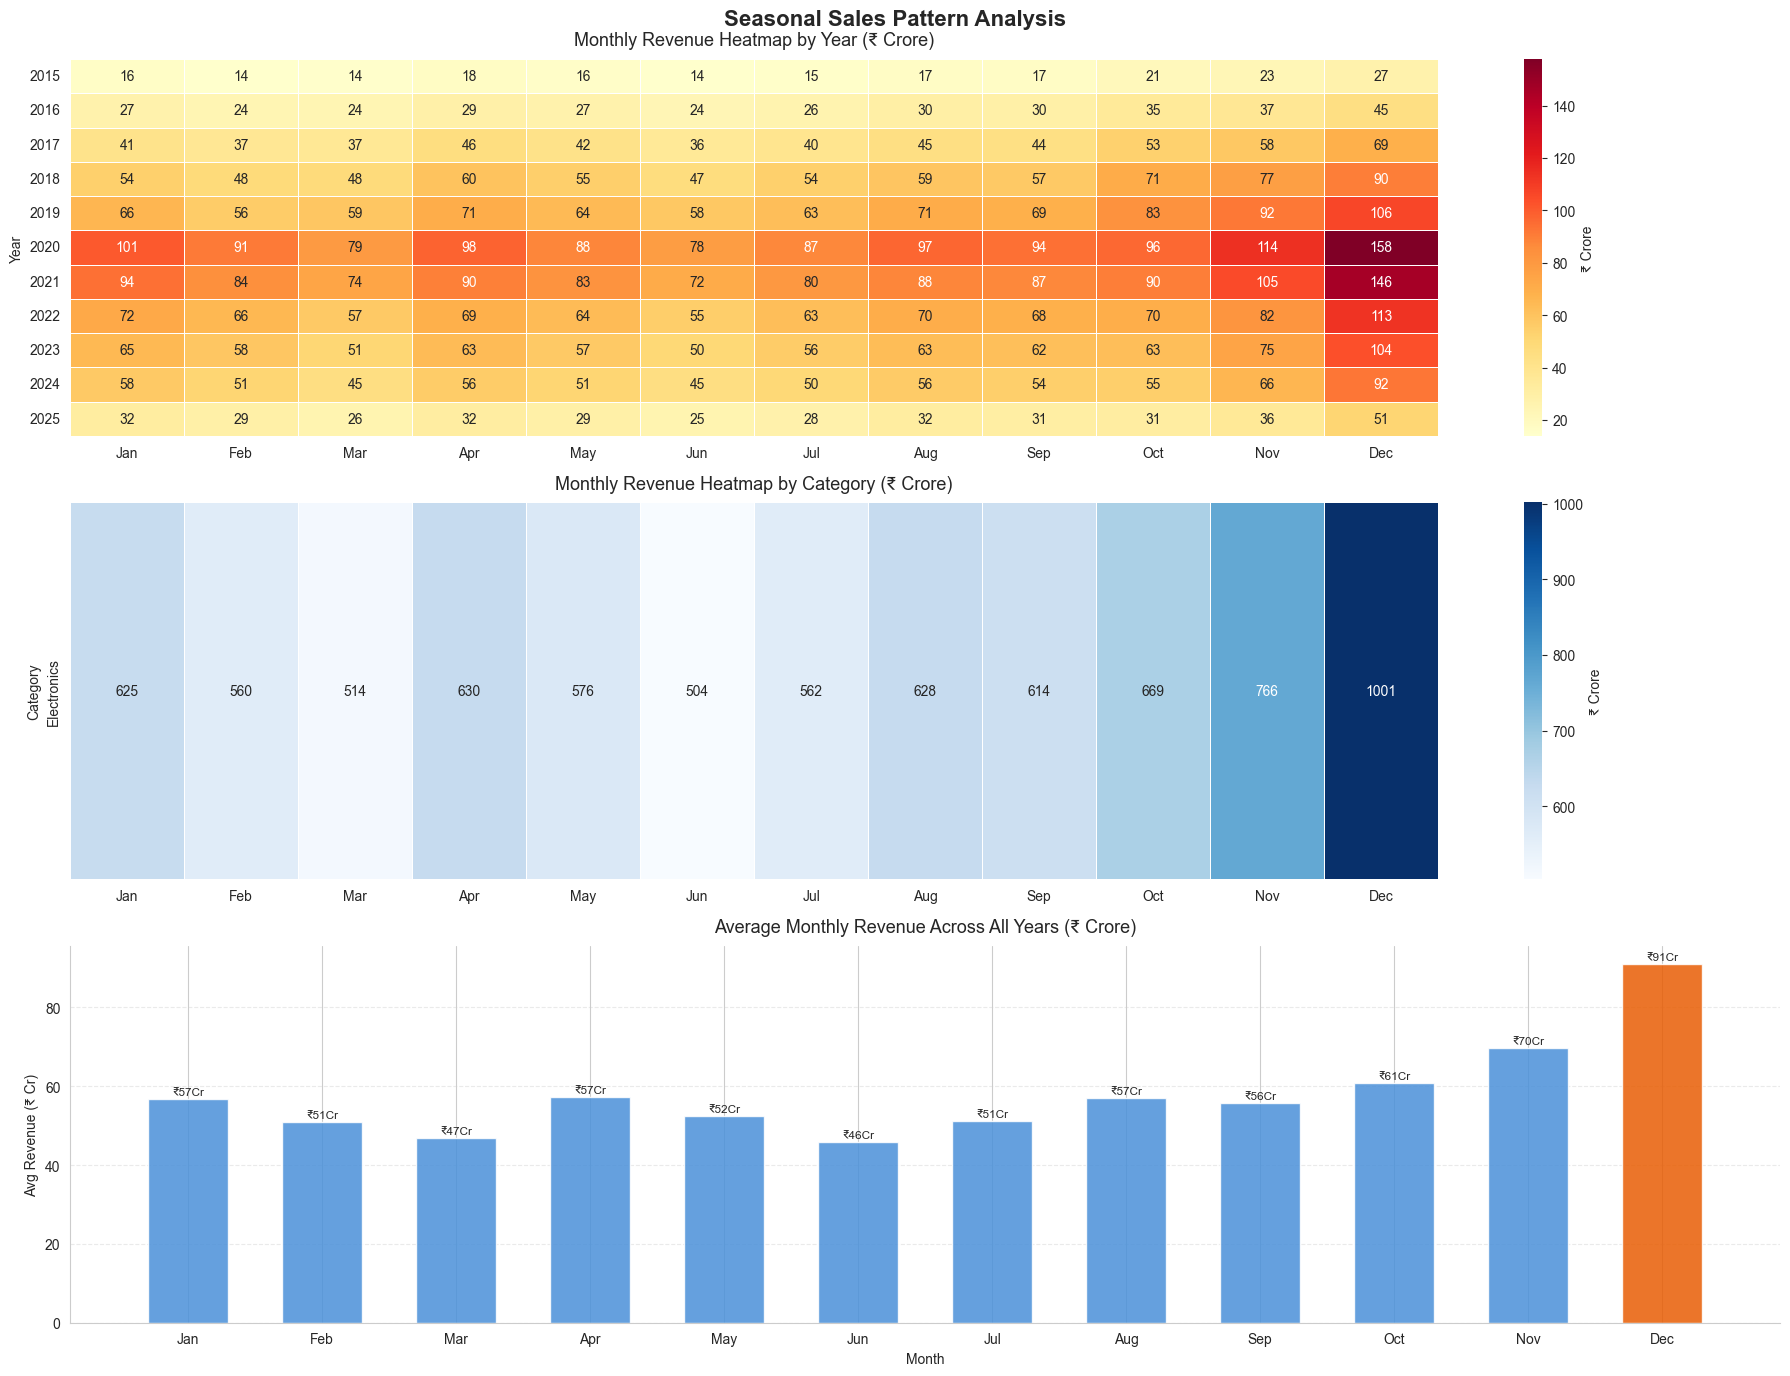


── Year × Month Revenue (₹ Cr) ──
               Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct     Nov     Dec
order_year                                                                                       
2015         16.23  14.32  14.48  17.68  15.62  13.91  15.44  16.98  17.02  21.09   23.16   27.09
2016         26.85  24.47  24.27  28.68  27.27  23.72  26.03  30.08  29.57  34.97   37.28   44.81
2017         41.04  37.31  36.90  45.67  41.99  36.29  39.53  44.77  44.14  53.35   58.17   68.82
2018         53.82  48.38  47.67  60.37  54.77  47.05  54.23  59.41  57.22  71.22   77.06   90.12
2019         65.63  56.05  58.70  70.53  64.07  57.81  62.71  70.80  68.60  83.40   91.72  106.33
2020        100.81  90.93  79.37  98.06  87.90  78.31  87.11  96.52  94.20  96.34  114.07  157.75
2021         93.73  84.39  74.25  89.50  82.97  71.50  80.34  88.00  87.02  90.12  105.19  146.40
2022         72.00  65.54  57.27  68.76  63.68  55.07  62.52  70.30  68.48  70.01  

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

df = amazon_india_2015_2025.copy()

# ── 1. Monthly revenue (₹ Cr) pivot ──────────────────────────────────────────
monthly = (
    df.groupby(['order_year', 'order_month'])['final_amount_inr']
    .sum()
    .reset_index()
)
monthly['revenue_cr'] = (monthly['final_amount_inr'] / 1e7).round(2)

pivot = monthly.pivot(index='order_year', columns='order_month', values='revenue_cr')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

# ── 2. Peak selling month per year ───────────────────────────────────────────
peak_months = pivot.idxmax(axis=1)
print("Peak selling month per year:")
print(peak_months.to_string())

# ── 3. Overall peak month across all years ───────────────────────────────────
overall_peak = pivot.sum().idxmax()
print(f"\nOverall peak month (all years combined): {overall_peak}")

# ── 4. Category × Month heatmap data ─────────────────────────────────────────
cat_month = (
    df.groupby(['category', 'order_month'])['final_amount_inr']
    .sum()
    .reset_index()
)
cat_month['revenue_cr'] = (cat_month['final_amount_inr'] / 1e7).round(2)
cat_pivot = cat_month.pivot(index='category', columns='order_month', values='revenue_cr')
cat_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Seasonal Sales Pattern Analysis', fontsize=16, fontweight='bold', y=0.98)

# ── 5a. Year × Month heatmap ──────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 1, 1)
sns.heatmap(
    pivot,
    ax=ax1,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': '₹ Crore'}
)
ax1.set_title('Monthly Revenue Heatmap by Year (₹ Crore)', fontsize=13, pad=10)
ax1.set_xlabel('')
ax1.set_ylabel('Year')

# ── 5b. Category × Month heatmap ─────────────────────────────────────────────
ax2 = fig.add_subplot(3, 1, 2)
sns.heatmap(
    cat_pivot,
    ax=ax2,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': '₹ Crore'}
)
ax2.set_title('Monthly Revenue Heatmap by Category (₹ Crore)', fontsize=13, pad=10)
ax2.set_xlabel('')
ax2.set_ylabel('Category')

# ── 5c. Monthly avg revenue bar (all years) ───────────────────────────────────
ax3 = fig.add_subplot(3, 1, 3)
monthly_avg = pivot.mean()
colors = ['#e85d04' if m == overall_peak else '#4a90d9' for m in monthly_avg.index]
bars = ax3.bar(monthly_avg.index, monthly_avg.values, color=colors, alpha=0.85, width=0.6)

for bar, val in zip(bars, monthly_avg.values):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        f'₹{val:.0f}Cr',
        ha='center', va='bottom', fontsize=8.5
    )

ax3.set_title('Average Monthly Revenue Across All Years (₹ Crore)', fontsize=13, pad=10)
ax3.set_xlabel('Month')
ax3.set_ylabel('Avg Revenue (₹ Cr)')
ax3.grid(axis='y', linestyle='--', alpha=0.4)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('seasonal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Summary tables ─────────────────────────────────────────────────────────
print("\n── Year × Month Revenue (₹ Cr) ──")
print(pivot.to_string())

print("\n── Category × Month Revenue (₹ Cr) ──")
print(cat_pivot.to_string())

3.Customer Segmentation Using RFM (Recency, Frequency, Monetary) Analysis

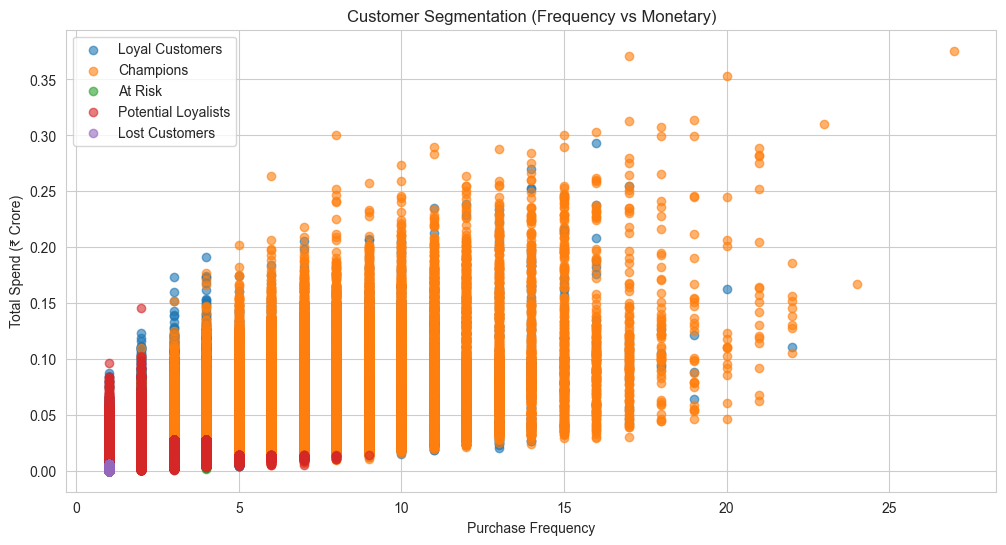

            segment  customers  avg_recency  avg_frequency  avg_monetary_cr  total_revenue_cr
Potential Loyalists     100614      1362.81           2.04             0.01           1143.65
    Loyal Customers      98514      1386.02           3.73             0.03           2660.54
          Champions      78437       774.81           5.77             0.04           3407.10
            At Risk      62358      1798.46           1.30             0.01            388.95
     Lost Customers      15046      2540.69           1.00             0.00             49.56


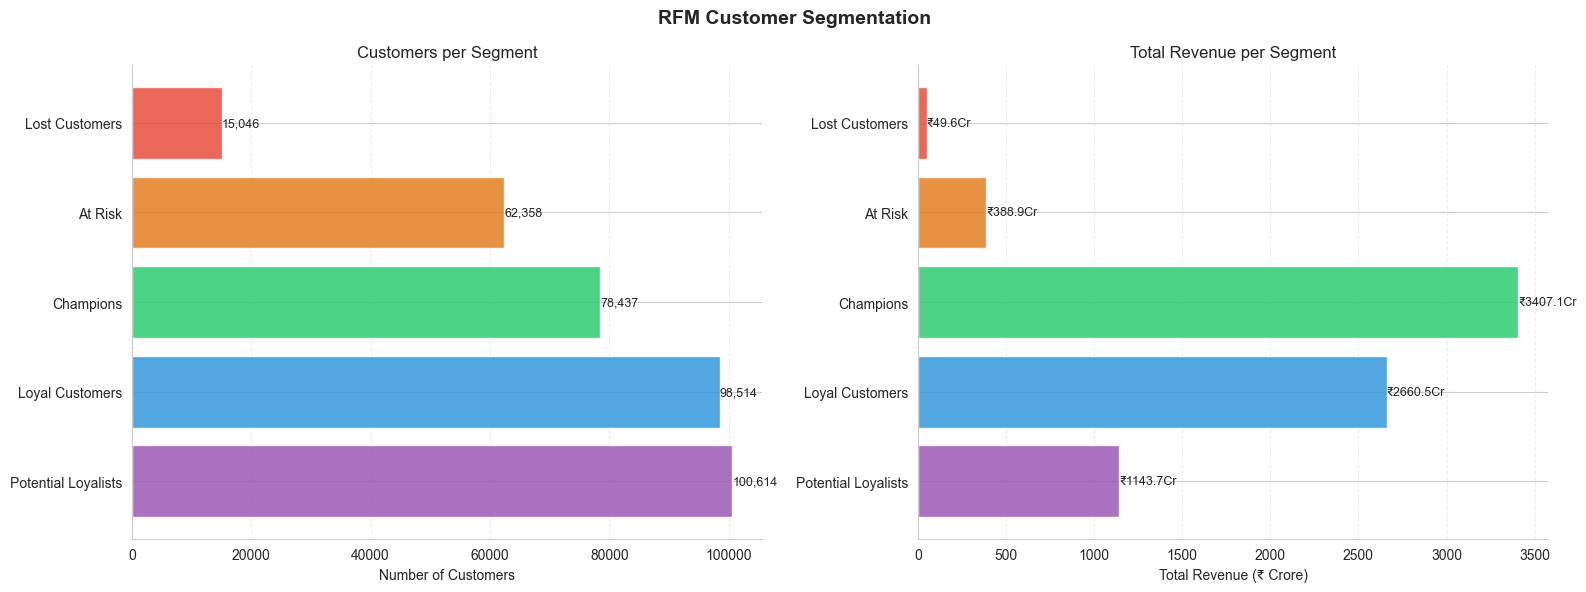

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ===============================
# 1️⃣ Reference Date (latest order)
# ===============================
snapshot_date = amazon_india_2015_2025['order_date'].max() + pd.Timedelta(days=1)

# ===============================
# 2️⃣ Build RFM Table
# ===============================
rfm = (
    amazon_india_2015_2025
    .groupby('customer_id')
    .agg({
        'order_date': lambda x: (snapshot_date - x.max()).days,   # Recency
        'transaction_id': 'count',                                # Frequency
        'final_amount_inr': 'sum'                                 # Monetary
    })
    .reset_index()
)

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Convert monetary to crores
rfm['monetary_cr'] = (rfm['monetary'] / 1e7).round(4)

# ===============================
# 3️⃣ RFM Scoring (BULLETPROOF)
# ===============================

# Recency (lower is better → reverse labels)
rfm['R_score'] = pd.qcut(
    rfm['recency'].rank(method='first'),
    4,
    labels=[4,3,2,1]
)

# Frequency (higher is better)
rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

# Monetary (higher is better)
rfm['M_score'] = pd.qcut(
    rfm['monetary_cr'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm[['R_score','F_score','M_score']] = (
    rfm[['R_score','F_score','M_score']]
    .astype(int)
)

rfm['RFM_score'] = (
    rfm['R_score'] +
    rfm['F_score'] +
    rfm['M_score']
)

# ===============================
# 4️⃣ Customer Segments
# ===============================
def segment_customer(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['segment'] = rfm['RFM_score'].apply(segment_customer)

# ===============================
# 5️⃣ Scatter Plot: Frequency vs Monetary
# ===============================
plt.figure(figsize=(12, 6))

for seg in rfm['segment'].unique():
    temp = rfm[rfm['segment'] == seg]
    plt.scatter(
        temp['frequency'],
        temp['monetary_cr'],
        alpha=0.6,
        label=seg
    )

plt.title('Customer Segmentation (Frequency vs Monetary)')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spend (₹ Crore)')
plt.legend()
plt.grid(True)

plt.show()

# ===============================
# 6️⃣ Segment Summary Table
# ===============================
segment_summary = (
    rfm
    .groupby('segment')
    .agg(
        customers       = ('customer_id', 'count'),
        avg_recency     = ('recency', 'mean'),
        avg_frequency   = ('frequency', 'mean'),
        avg_monetary_cr = ('monetary_cr', 'mean'),
        total_revenue_cr= ('monetary_cr', 'sum')
    )
    .round(2)
    .sort_values('customers', ascending=False)
    .reset_index()
)

print(segment_summary.to_string(index=False))

# ===============================
# 7️⃣ Panel 3 & 4 — Bar Charts
# ===============================
seg_colors = {
    'Champions':          '#2ecc71',
    'Loyal Customers':    '#3498db',
    'Potential Loyalists':'#9b59b6',
    'At Risk':            '#e67e22',
    'Lost Customers':     '#e74c3c',
}

seg_order  = segment_summary['segment'].tolist()
bar_colors = [seg_colors[s] for s in seg_order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')

# Panel 3 — Customers per Segment
bars1 = ax1.barh(seg_order, segment_summary['customers'], color=bar_colors, alpha=0.85)
for bar, val in zip(bars1, segment_summary['customers']):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_xlabel('Number of Customers')
ax1.set_title('Customers per Segment')
ax1.grid(axis='x', linestyle='--', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# Panel 4 — Total Revenue per Segment
bars2 = ax2.barh(seg_order, segment_summary['total_revenue_cr'], color=bar_colors, alpha=0.85)
for bar, val in zip(bars2, segment_summary['total_revenue_cr']):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'₹{val:.1f}Cr', va='center', fontsize=9)
ax2.set_xlabel('Total Revenue (₹ Crore)')
ax2.set_title('Total Revenue per Segment')
ax2.grid(axis='x', linestyle='--', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

4.Evolution of Payment Methods and Market Share Trends (2015–2025)

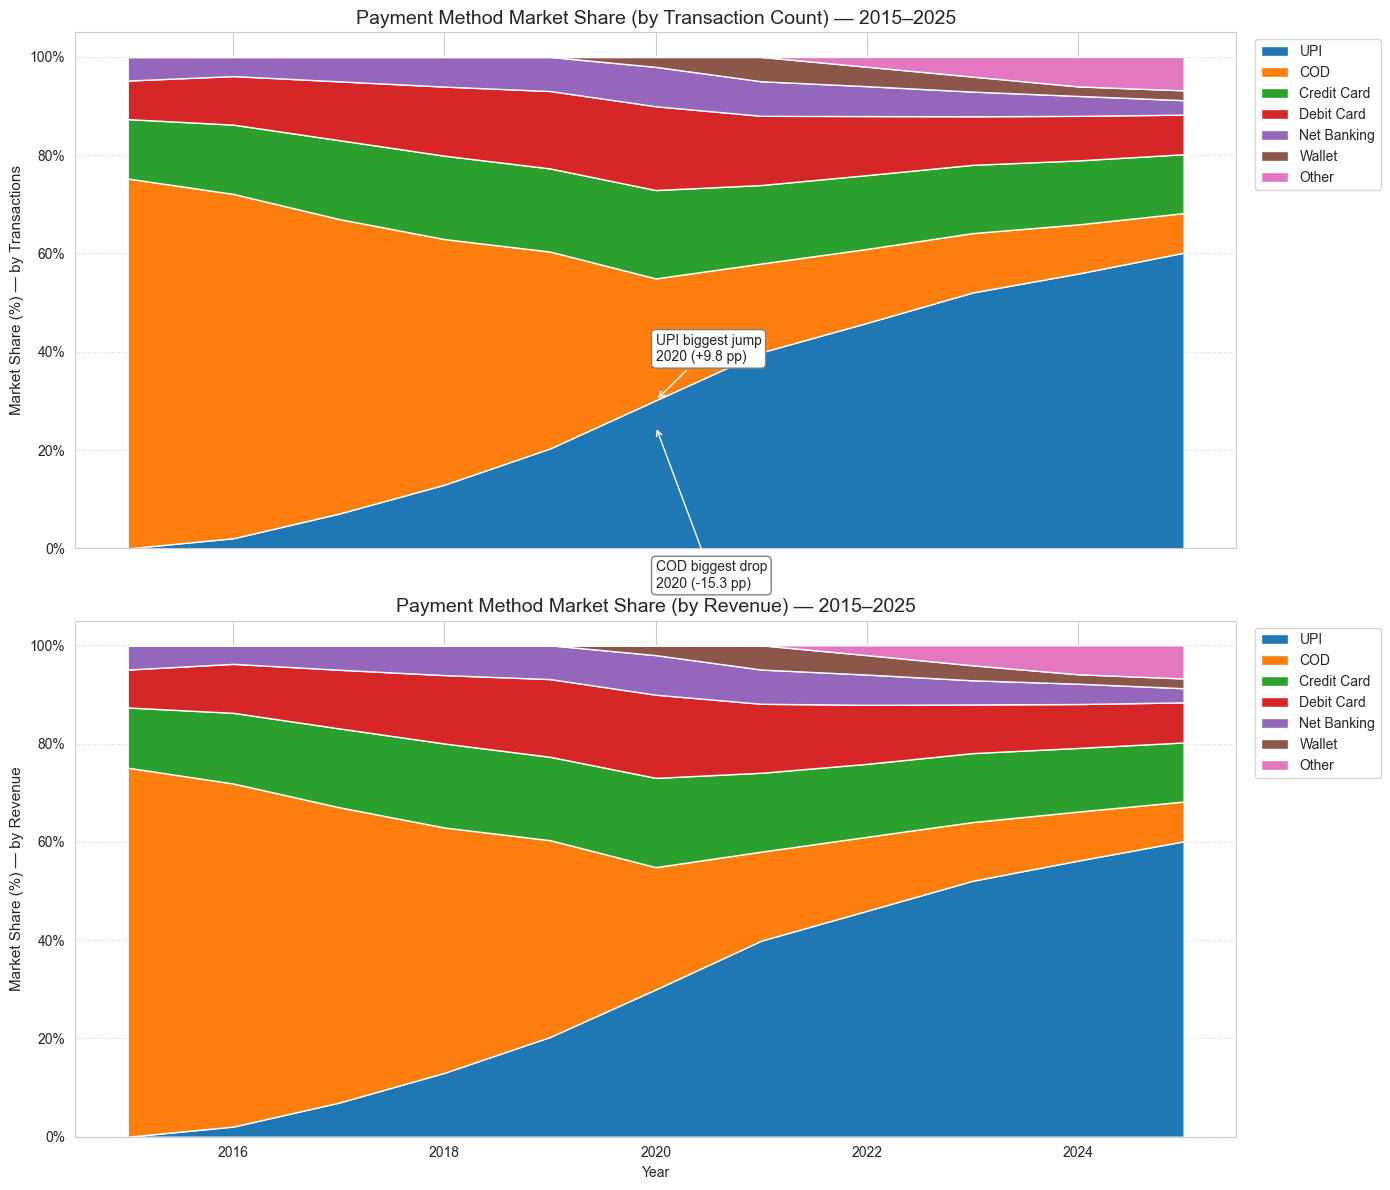


Top payment methods by total transactions (2015-2025):
payment_method
UPI            382356.0
COD            321262.0
Credit Card    171396.0
Debit Card     139490.0
Net Banking     64620.0
Wallet          22678.0
Other           20198.0
dtype: float64

Sample: Year-wise UPI & COD % (if present):


payment_method,UPI,COD
order_year,,
2015,0.00,75.26
2016,2.06,70.06
2017,7.07,59.95
2018,12.97,49.97
2019,20.34,40.06
2020,30.13,24.80
2021,39.88,18.08
2022,45.88,15.05
2023,52.07,12.08



Insights:
- UPI change (2015→2025): 60.2 percentage points (by transactions).
- COD change (2015→2025): -67.2 percentage points (by transactions).


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ---------------------------
# CONFIG / SAFETY
# ---------------------------
# Ensure order_year and payment_method exist
df = amazon_india_2015_2025  # adjust name if needed
assert 'order_year' in df.columns and 'payment_method' in df.columns

# ---------------------------
# 1) Prepare counts and revenue by year x payment_method
# ---------------------------
# Optionally limit to years 2015-2025 if dataset contains other years
years_mask = (df['order_year'] >= 2015) & (df['order_year'] <= 2025)
data = df.loc[years_mask, :].copy()

# Count-based market share
count_tbl = (
    data
    .groupby(['order_year', 'payment_method'])['transaction_id']
    .count()
    .rename('tx_count')
    .reset_index()
)

pivot_count = count_tbl.pivot(index='order_year', columns='payment_method', values='tx_count').fillna(0)

# Revenue-based market share (alternate view)
rev_tbl = (
    data
    .groupby(['order_year', 'payment_method'])['final_amount_inr']
    .sum()
    .rename('revenue')
    .reset_index()
)
pivot_rev = rev_tbl.pivot(index='order_year', columns='payment_method', values='revenue').fillna(0)

# ---------------------------
# 2) Consolidate small columns into "Other"
# ---------------------------
def consolidate_small_columns(pivot_df, top_n=6):
    # pick top_n methods by cumulative share across years
    totals = pivot_df.sum().sort_values(ascending=False)
    top = totals.head(top_n).index.tolist()
    others = [c for c in pivot_df.columns if c not in top]
    df_top = pivot_df[top].copy()
    if others:
        df_top['Other'] = pivot_df[others].sum(axis=1)
    return df_top

top_n = 6
pc = consolidate_small_columns(pivot_count, top_n=top_n)
pr = consolidate_small_columns(pivot_rev, top_n=top_n)

# Sort columns so UPI and COD (if present) are easy to find and order is consistent
cols_order = [c for c in pc.columns if c in ['UPI', 'COD']] + [c for c in pc.columns if c not in ['UPI', 'COD']]
pc = pc[cols_order]
pr = pr[[c for c in cols_order if c in pr.columns]]  # align revenue pivot columns similarly if exists

# ---------------------------
# 3) Convert to % market share by year
# ---------------------------
pc_share = pc.div(pc.sum(axis=1), axis=0)*100
pr_share = pr.div(pr.sum(axis=1), axis=0)*100

years = pc_share.index.values

# ---------------------------
# 4) Find key inflection years for annotations
# ---------------------------
def first_large_change(series_pct, direction='increase', top_k=1):
    # compute year-over-year change in percentage points
    diff = series_pct.diff().fillna(0)
    if direction == 'increase':
        idx = diff.idxmax()
    else:
        idx = diff.idxmin()
    return idx, diff.loc[idx]

upi_year = (None, None)
cod_year = (None, None)
if 'UPI' in pc_share.columns:
    upi_year = first_large_change(pc_share['UPI'], 'increase')
if 'COD' in pc_share.columns:
    cod_year = first_large_change(pc_share['COD'], 'decrease')

# ---------------------------
# 5) Plot stacked area charts (count-share and revenue-share)
# ---------------------------
fig, axes = plt.subplots(2, 1, figsize=(14,12), sharex=True)

# A) Count-based market share stacked area
ax = axes[0]
labels = pc_share.columns.tolist()
yvals = [pc_share[c].values for c in labels]
ax.stackplot(years, yvals, labels=labels)
ax.set_ylabel('Market Share (%) — by Transactions', fontsize=11)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_title('Payment Method Market Share (by Transaction Count) — 2015–2025', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Annotate UPI rise and COD decline if present
if upi_year[0] is not None:
    ax.annotate(
        f"UPI biggest jump\n{upi_year[0]} (+{upi_year[1]:.1f} pp)",
        xy=(upi_year[0], pc_share.loc[upi_year[0], 'UPI']),
        xytext=(upi_year[0], pc_share.loc[upi_year[0]].max()+8),
        arrowprops=dict(arrowstyle='->'),
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.5")
    )
if cod_year[0] is not None:
    ax.annotate(
        f"COD biggest drop\n{cod_year[0]} ({cod_year[1]:.1f} pp)",
        xy=(cod_year[0], pc_share.loc[cod_year[0], 'COD']),
        xytext=(cod_year[0], pc_share.loc[cod_year[0]].min()-8),
        arrowprops=dict(arrowstyle='->'),
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.5")
    )

ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

# B) Revenue-based market share stacked area
ax = axes[1]
labels_rev = pr_share.columns.tolist()
yvals_rev = [pr_share[c].values for c in labels_rev]
ax.stackplot(years, yvals_rev, labels=labels_rev)
ax.set_ylabel('Market Share (%) — by Revenue', fontsize=11)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_title('Payment Method Market Share (by Revenue) — 2015–2025', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.xlabel('Year')
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Show summary tables for interpretation
# ---------------------------
print("\nTop payment methods by total transactions (2015-2025):")
print(pc.sum().sort_values(ascending=False).head(10))

print("\nSample: Year-wise UPI & COD % (if present):")
cols_to_show = [c for c in ['UPI','COD'] if c in pc_share.columns]
display(pc_share[cols_to_show].round(2))

# ---------------------------
# 7) Short textual insights (print)
# ---------------------------
print("\nInsights:")
if 'UPI' in pc_share.columns:
    upi_trend = pc_share['UPI'].iloc[-1] - pc_share['UPI'].iloc[0]
    print(f"- UPI change (2015→2025): {upi_trend:.1f} percentage points (by transactions).")
else:
    print("- UPI not present in payment_method column.")

if 'COD' in pc_share.columns:
    cod_trend = pc_share['COD'].iloc[-1] - pc_share['COD'].iloc[0]
    print(f"- COD change (2015→2025): {cod_trend:.1f} percentage points (by transactions).")
else:
    print("- COD not present in payment_method column.")

5.Category-Wise Performance Analysis: Revenue Contribution, Growth Rates, and Market Share

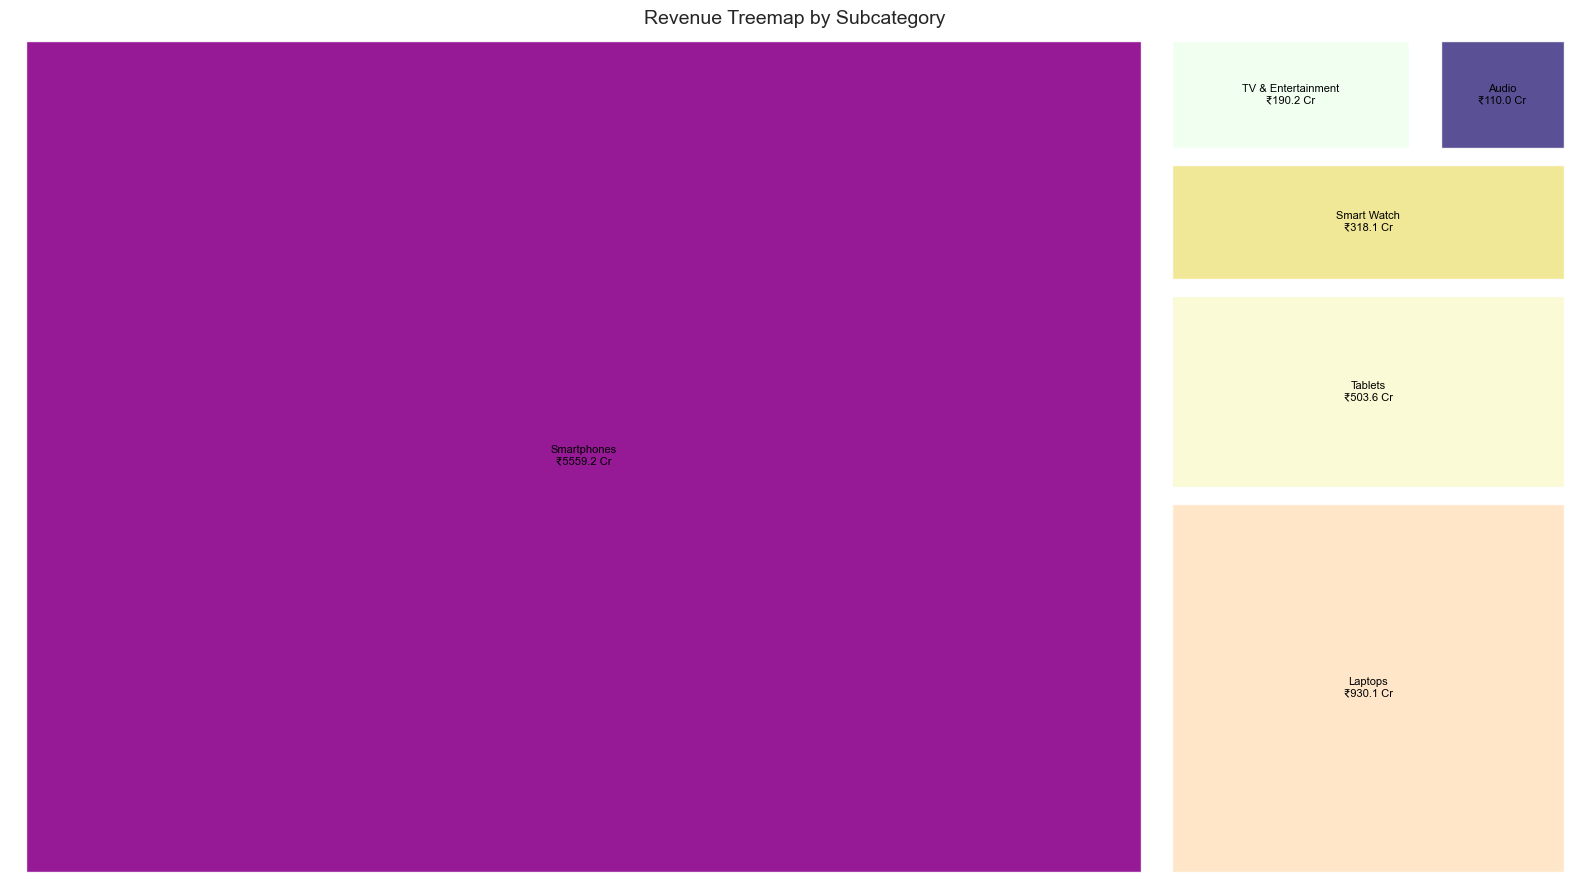

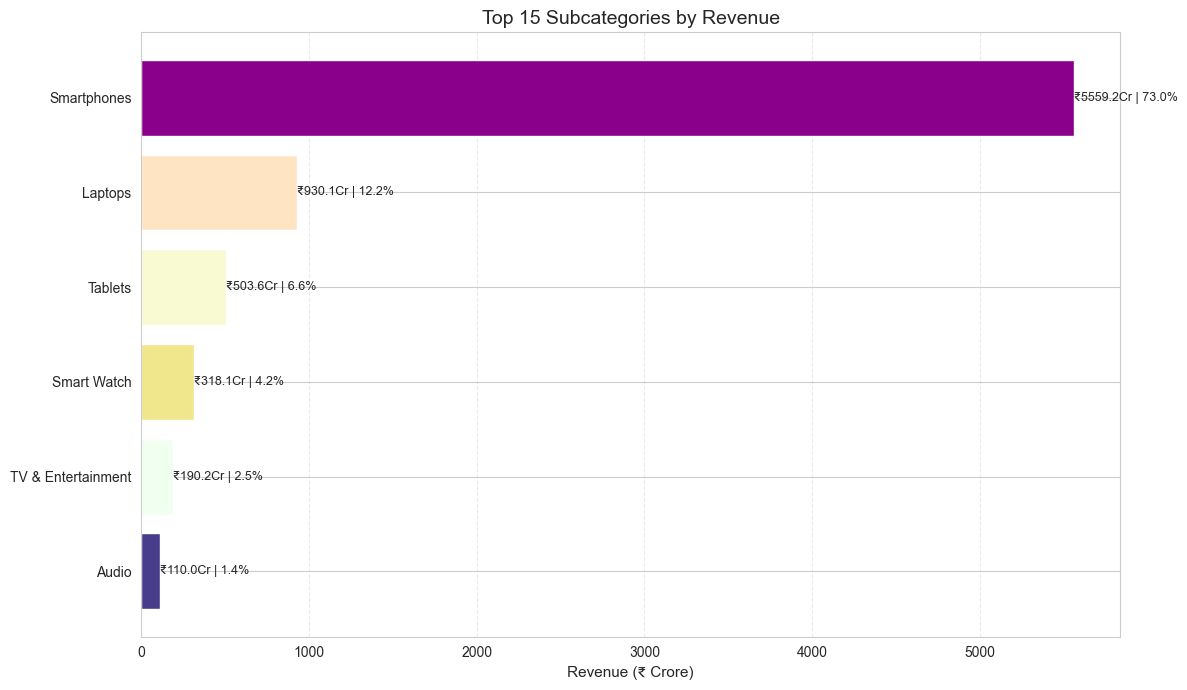

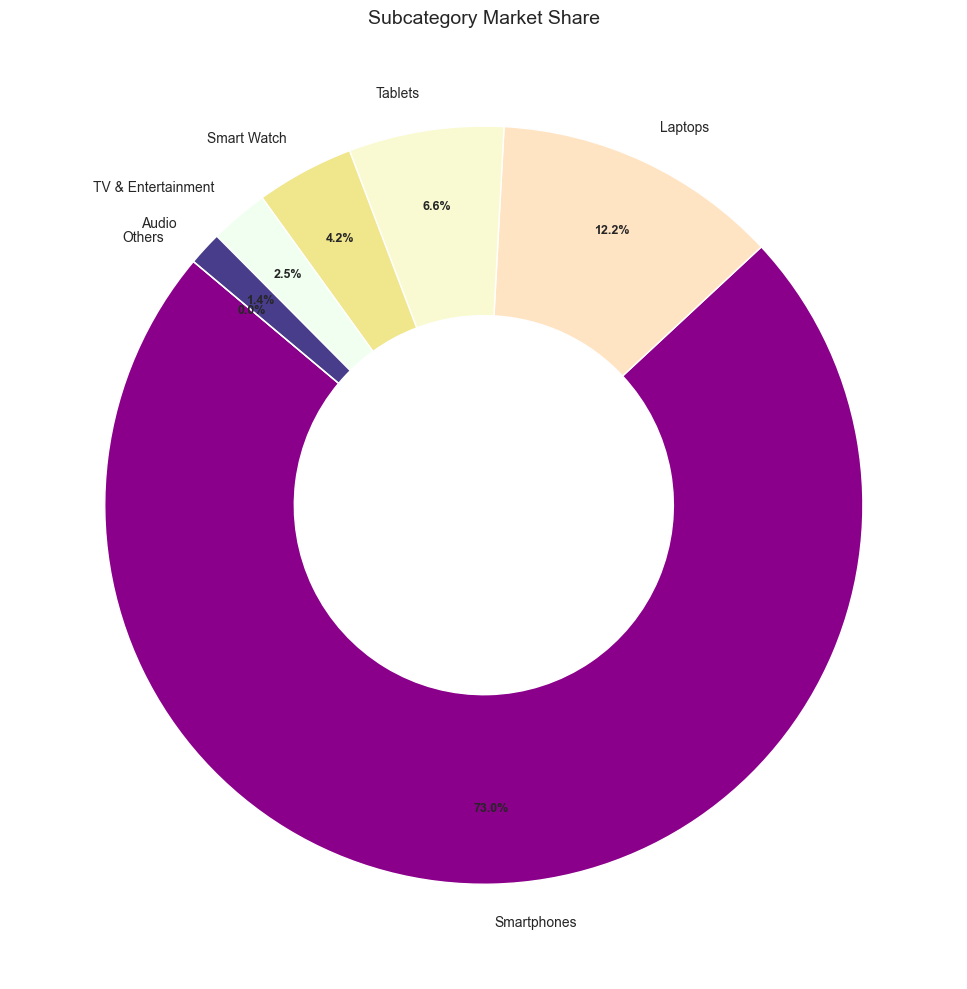

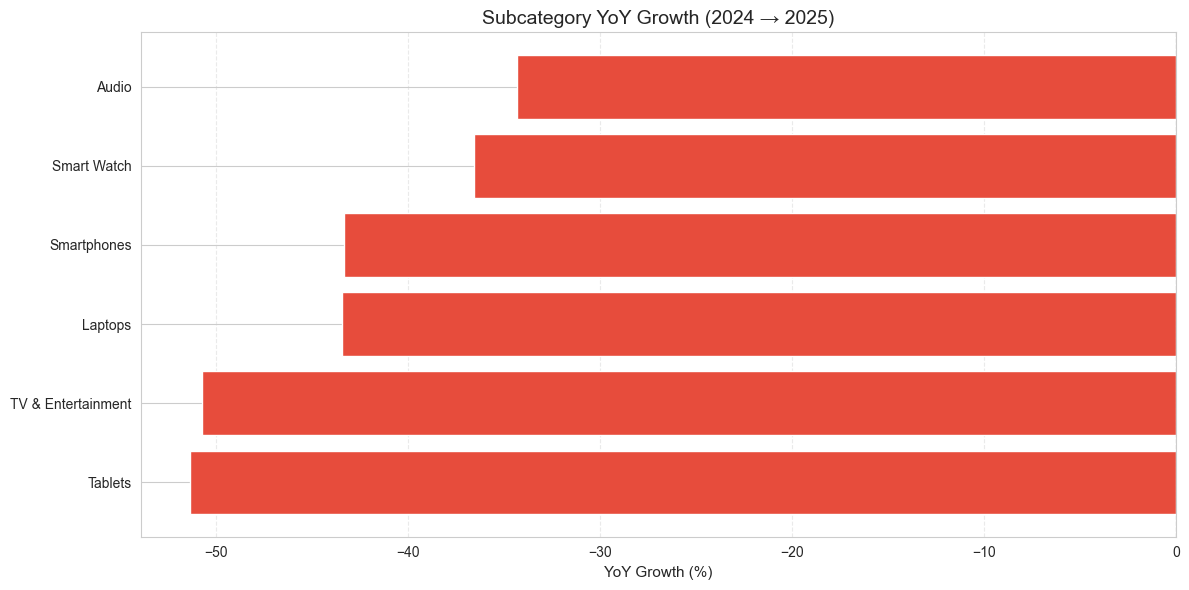


Top Revenue Subcategories

   category        subcategory  revenue_cr  share_pct
Electronics        Smartphones 5559.232047  73.039975
Electronics            Laptops  930.127399  12.220480
Electronics            Tablets  503.557782   6.615994
Electronics        Smart Watch  318.088666   4.179208
Electronics TV & Entertainment  190.226331   2.499289
Electronics              Audio  109.986255   1.445055


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify
import numpy as np
import matplotlib.colors as mcolors
import random

# =============================================================================
# LOAD DATA
# =============================================================================

df = amazon_india_2015_2025.copy()

# =============================================================================
# DATA CLEANING
# =============================================================================

# Remove duplicates
data = df[df['is_duplicate'] == False].copy()

# Clean text columns
for col in ['category', 'subcategory']:
    data[col] = (
        data[col]
        .astype(str)
        .str.strip()
    )

# Remove null revenue rows
data = data.dropna(subset=['final_amount_inr'])

# =============================================================================
# AGGREGATE REVENUE
# =============================================================================

sub = (
    data.groupby(
        ['category', 'subcategory'],
        as_index=False
    )['final_amount_inr']
    .sum()
    .sort_values(
        'final_amount_inr',
        ascending=False
    )
)

# Total revenue
total_revenue = sub['final_amount_inr'].sum()

# Share %
sub['share_pct'] = (
    sub['final_amount_inr']
    / total_revenue
) * 100

# Revenue in Crores
sub['revenue_cr'] = (
    sub['final_amount_inr']
    / 1e7
)

# =============================================================================
# RANDOM DISTINCT COLORS
# =============================================================================

all_colors = list(mcolors.CSS4_COLORS.values())

random.seed(42)

unique_subcats = sub['subcategory'].unique()

subcat_colors = {
    subcat: random.choice(all_colors)
    for subcat in unique_subcats
}

# =============================================================================
# STYLE
# =============================================================================

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 11
})

# =============================================================================
# 1. TREEMAP — TOP 30 SUBCATEGORIES
# =============================================================================

top30 = sub.head(30)

fig, ax = plt.subplots(figsize=(16, 9))

labels = top30.apply(
    lambda r:
    f"{r['subcategory']}\n₹{r['revenue_cr']:.1f} Cr",
    axis=1
)

squarify.plot(
    sizes=top30['revenue_cr'],

    label=labels,

    color=[
        subcat_colors.get(sc, 'grey')
        for sc in top30['subcategory']
    ],

    alpha=0.9,

    pad=True,

    text_kwargs={
        'fontsize': 8,
        'color': 'black'
    },

    ax=ax
)

ax.set_title(
    'Revenue Treemap by Subcategory'
)

ax.axis('off')

plt.tight_layout()
plt.show()

# =============================================================================
# 2. BAR CHART — TOP 15 SUBCATEGORIES
# =============================================================================

top15 = (
    sub.head(15)
    .sort_values('revenue_cr')
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(

    top15['subcategory'],

    top15['revenue_cr'],

    color=[
        subcat_colors.get(sc, 'grey')
        for sc in top15['subcategory']
    ]
)

# Labels
for bar, revenue, pct in zip(
    bars,
    top15['revenue_cr'],
    top15['share_pct']
):

    ax.text(
        bar.get_width() + 0.1,

        bar.get_y() + bar.get_height()/2,

        f'₹{revenue:.1f}Cr | {pct:.1f}%',

        va='center',

        fontsize=9
    )

ax.set_xlabel('Revenue (₹ Crore)')

ax.set_title(
    'Top 15 Subcategories by Revenue'
)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

# =============================================================================
# 3. SUBCATEGORY MARKET SHARE
# =============================================================================

sub_share = (
    sub.groupby('subcategory')['final_amount_inr']
    .sum()
    .sort_values(ascending=False)
)

# Top 15 only
top_sub = sub_share.head(15)

# Others category
others = pd.Series({
    'Others': sub_share.iloc[15:].sum()
})

top_sub = pd.concat([top_sub, others])

fig, ax = plt.subplots(figsize=(10, 10))

wedges, texts, autotexts = ax.pie(

    top_sub.values,

    labels=top_sub.index,

    autopct='%1.1f%%',

    startangle=140,

    colors=[
        subcat_colors.get(sc, 'grey')
        for sc in top_sub.index
    ],

    wedgeprops={'width': 0.5},

    pctdistance=0.8
)

plt.setp(
    autotexts,
    size=9,
    weight='bold'
)

ax.set_title(
    'Subcategory Market Share'
)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. YOY GROWTH
# =============================================================================

years = sorted(
    data['order_year']
    .dropna()
    .astype(int)
    .unique()
)

if len(years) >= 2:

    cur, prev = years[-1], years[-2]

    r_cur = (
        data[data['order_year'] == cur]
        .groupby('subcategory')['final_amount_inr']
        .sum()
    )

    r_prev = (
        data[data['order_year'] == prev]
        .groupby('subcategory')['final_amount_inr']
        .sum()
    )

    growth = pd.concat(
        [r_prev, r_cur],
        axis=1
    )

    growth.columns = [
        'prev',
        'cur'
    ]

    # Avoid divide-by-zero
    growth = growth[
        growth['prev'] > 0
    ]

    growth['yoy_pct'] = (

        (growth['cur'] - growth['prev'])

        / growth['prev']

    ) * 100

    growth = (
        growth['yoy_pct']
        .sort_values()
    )

    fig, ax = plt.subplots(
        figsize=(
            12,
            max(6, len(growth) * 0.35)
        )
    )

    ax.barh(

        growth.index,

        growth.values,

        color=[
            '#e74c3c'
            if v < 0
            else '#2ecc71'

            for v in growth.values
        ]
    )

    ax.axvline(
        0,
        color='grey',
        linestyle='--',
        linewidth=0.8
    )

    ax.set_xlabel(
        'YoY Growth (%)'
    )

    ax.set_title(
        f'Subcategory YoY Growth ({prev} → {cur})'
    )

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()

else:
    print("Need at least 2 years of data.")

# =============================================================================
# SUMMARY TABLE
# =============================================================================

summary = sub[
    [
        'category',
        'subcategory',
        'revenue_cr',
        'share_pct'
    ]
].head(10)

print("\nTop Revenue Subcategories\n")

print(
    summary.to_string(index=False)
)

6.Impact of Prime Membership on Customer Behavior and Spending Patterns


Average Order Value:
is_prime_member
False    62023.837015
True     78200.715230
Name: final_amount_inr, dtype: float64


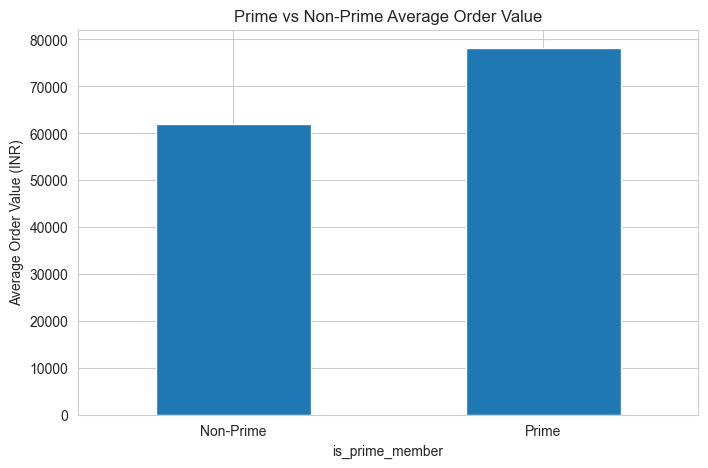

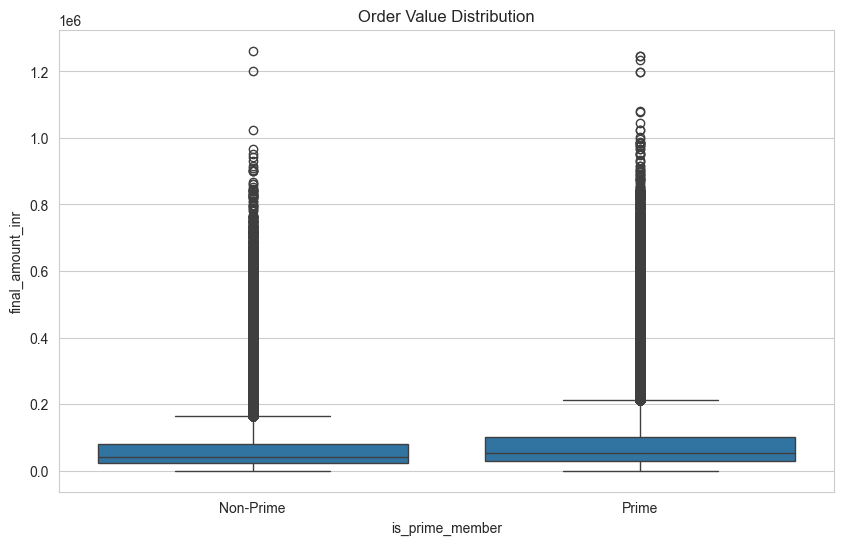

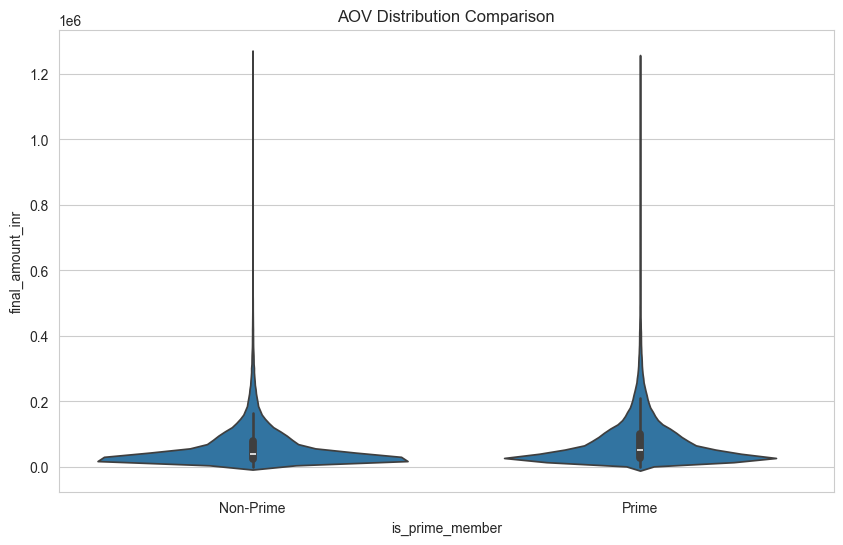


Average Order Frequency:
is_prime_member
False    3.576793
True     2.657778
Name: order_count, dtype: float64


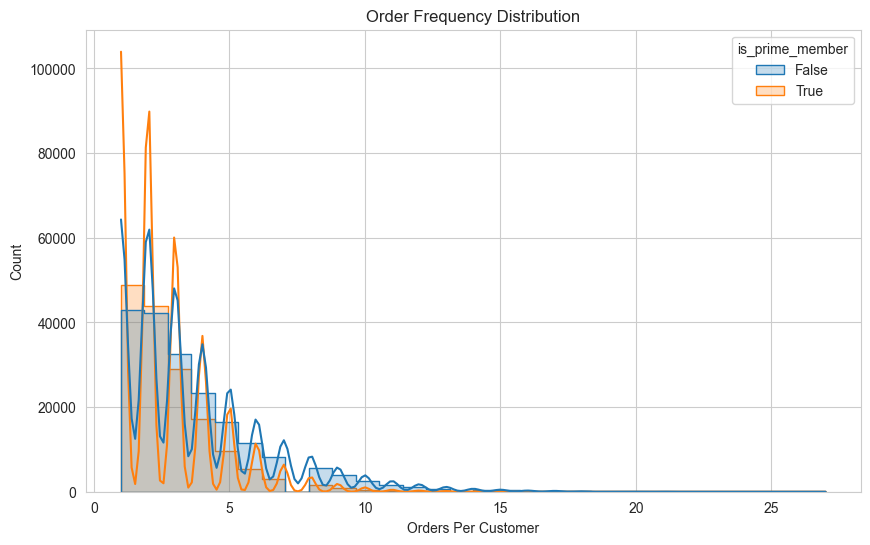

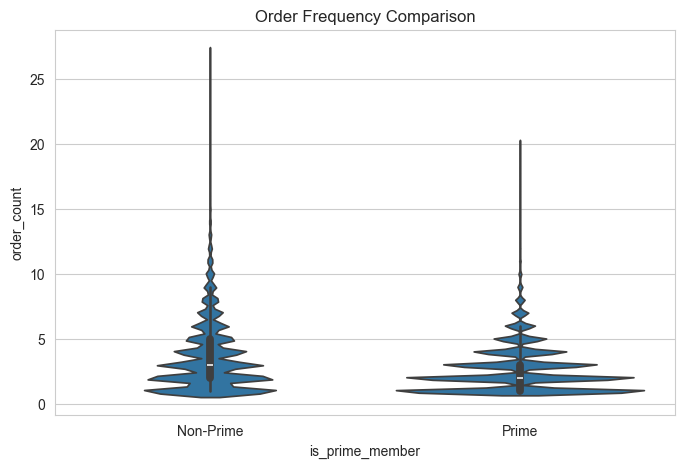

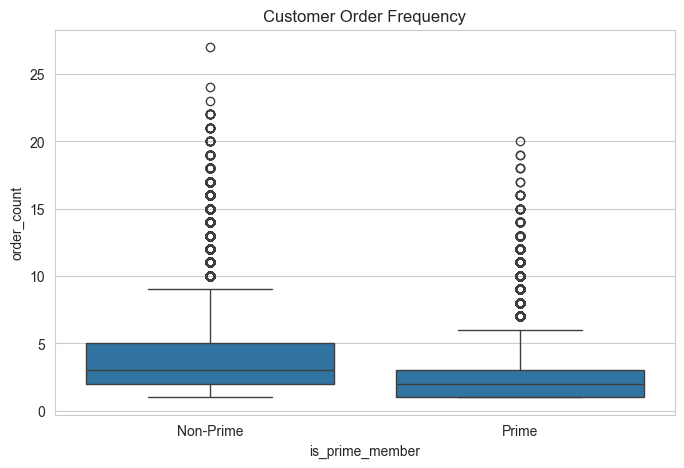

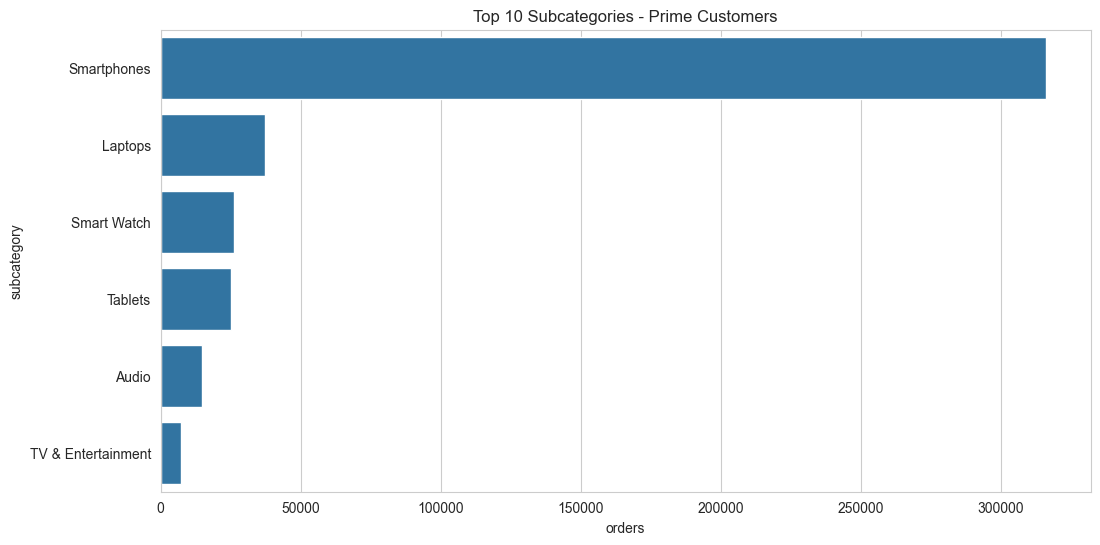

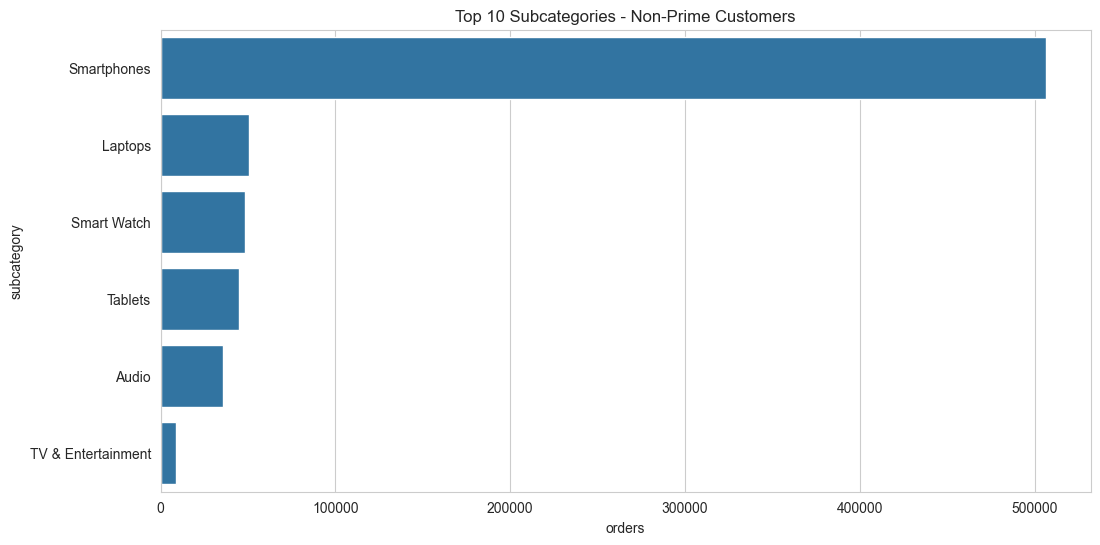

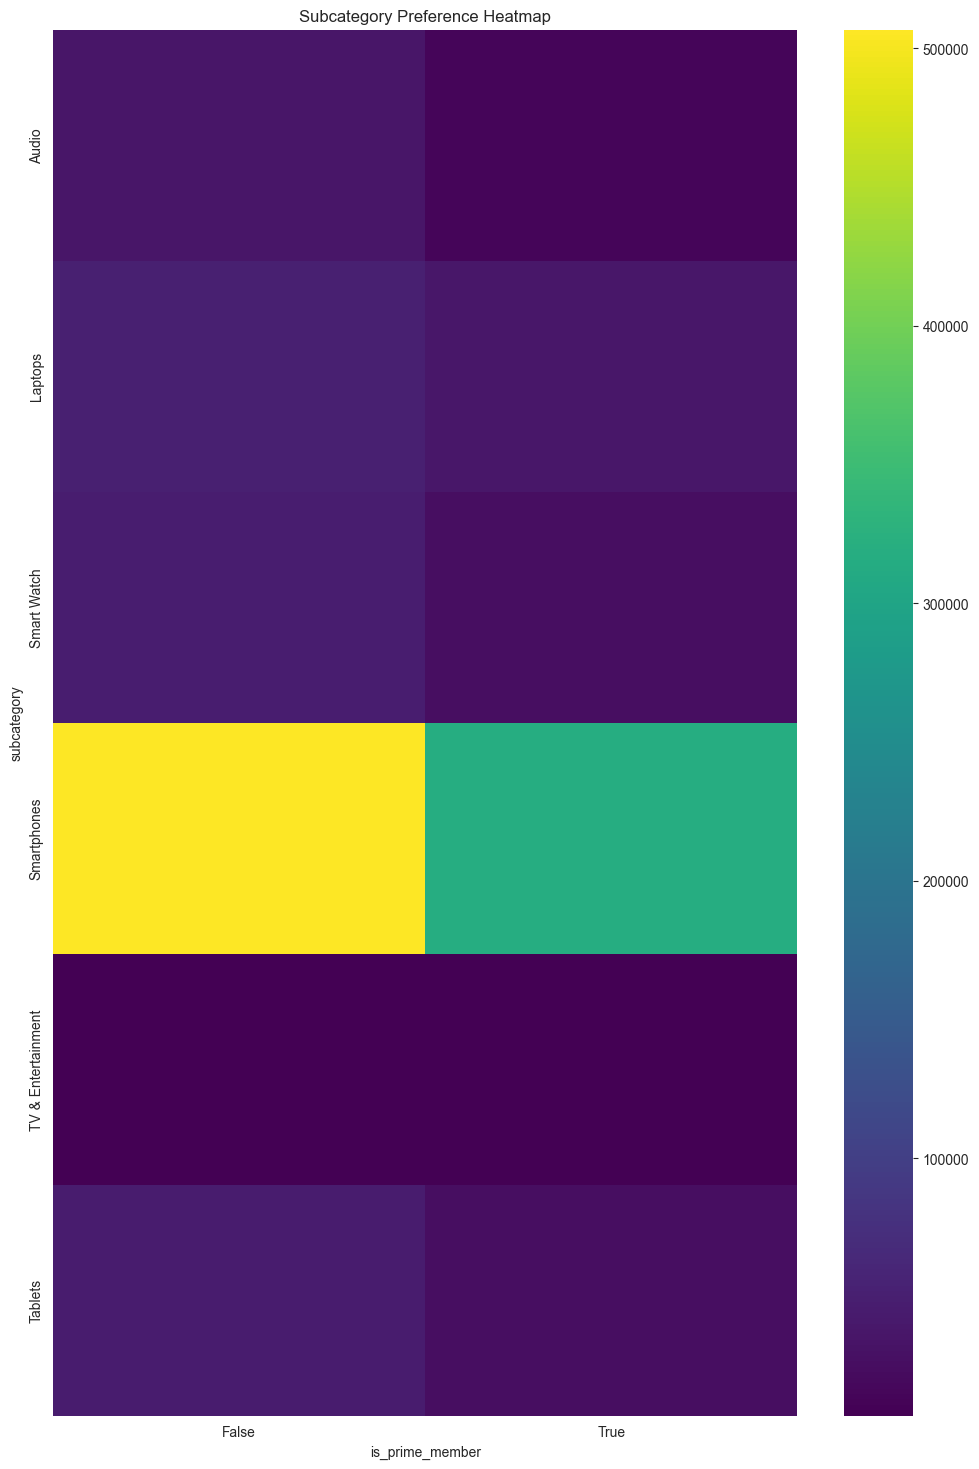

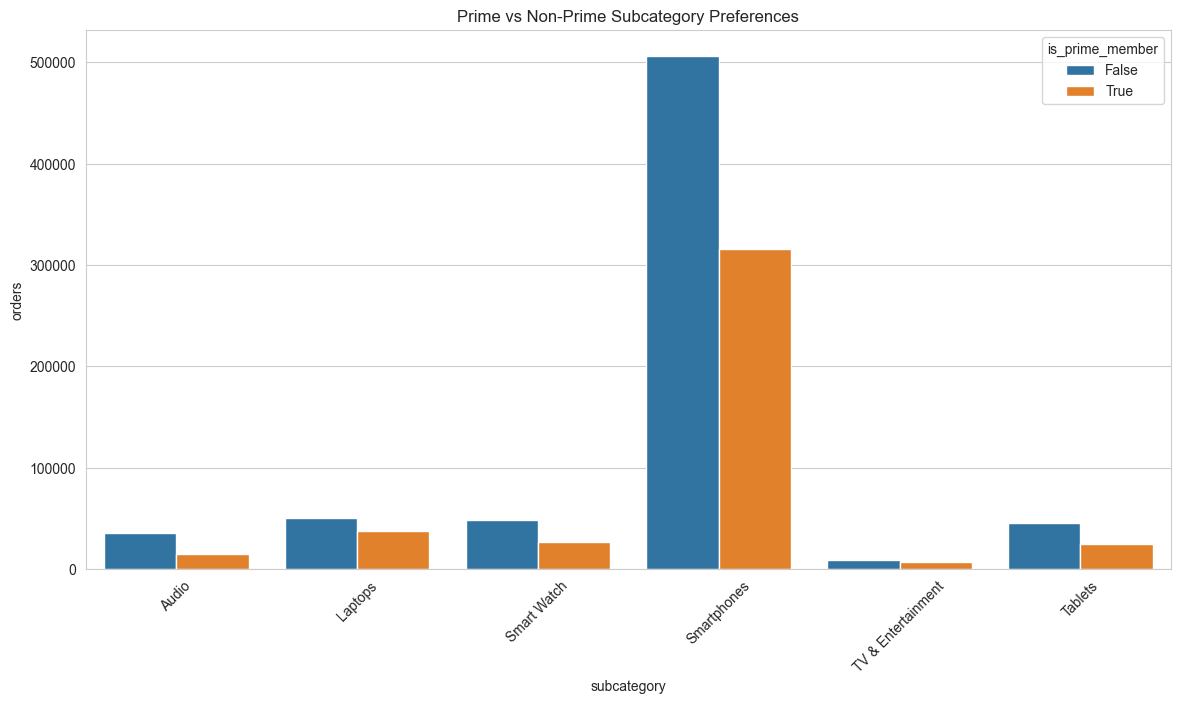


================ SUMMARY INSIGHTS ================

Prime customers have higher Average Order Value.
Non-Prime customers order more frequently.

Top Prime Customer Subcategories:
           subcategory  orders
9          Smartphones  316348
7              Laptops   37388
8          Smart Watch   26181
11             Tablets   24956
6                Audio   14763
10  TV & Entertainment    7368

Top Non-Prime Customer Subcategories:
          subcategory  orders
3         Smartphones  506726
1             Laptops   50513
2         Smart Watch   48154
5             Tablets   44971
0               Audio   35610
4  TV & Entertainment    9022


In [3]:
# ============================================================
# PRIME vs NON-PRIME CUSTOMER BEHAVIOR ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# AVERAGE ORDER VALUE (AOV)
# ============================================================

df = amazon_india_2015_2025.copy()

prime_aov = df.groupby('is_prime_member')['final_amount_inr'].mean()

print("\nAverage Order Value:")
print(prime_aov)

# Bar Chart
plt.figure(figsize=(8,5))
prime_aov.plot(kind='bar')

plt.xticks([0,1], ['Non-Prime', 'Prime'], rotation=0)
plt.ylabel('Average Order Value (INR)')
plt.title('Prime vs Non-Prime Average Order Value')

plt.show()

# Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='is_prime_member',
    y='final_amount_inr'
)

plt.xticks([0,1], ['Non-Prime', 'Prime'])
plt.title('Order Value Distribution')

plt.show()

# Violin Plot
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='is_prime_member',
    y='final_amount_inr'
)

plt.xticks([0,1], ['Non-Prime', 'Prime'])
plt.title('AOV Distribution Comparison')

plt.show()

# ============================================================
# ORDER FREQUENCY ANALYSIS
# ============================================================

customer_orders = (
    df.groupby(['customer_id', 'is_prime_member'])['transaction_id']
    .count()
    .reset_index(name='order_count')
)

freq_summary = customer_orders.groupby(
    'is_prime_member'
)['order_count'].mean()

print("\nAverage Order Frequency:")
print(freq_summary)

# Histogram
plt.figure(figsize=(10,6))

sns.histplot(
    data=customer_orders,
    x='order_count',
    hue='is_prime_member',
    bins=30,
    kde=True,
    element='step'
)

plt.title('Order Frequency Distribution')
plt.xlabel('Orders Per Customer')

plt.show()

# Violin Plot
plt.figure(figsize=(8,5))

sns.violinplot(
    data=customer_orders,
    x='is_prime_member',
    y='order_count'
)

plt.xticks([0,1], ['Non-Prime', 'Prime'])
plt.title('Order Frequency Comparison')

plt.show()

# Box Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customer_orders,
    x='is_prime_member',
    y='order_count'
)

plt.xticks([0,1], ['Non-Prime', 'Prime'])
plt.title('Customer Order Frequency')

plt.show()

# ============================================================
# SUBCATEGORY PREFERENCE ANALYSIS
# ============================================================

subcategory_pref = (
    df.groupby(['is_prime_member', 'subcategory'])['transaction_id']
    .count()
    .reset_index(name='orders')
)

# Prime Top 10
prime_top = (
    subcategory_pref[
        subcategory_pref['is_prime_member'] == True
    ]
    .sort_values('orders', ascending=False)
    .head(10)
)

# Non-Prime Top 10
nonprime_top = (
    subcategory_pref[
        subcategory_pref['is_prime_member'] == False
    ]
    .sort_values('orders', ascending=False)
    .head(10)
)

# Prime Subcategories
plt.figure(figsize=(12,6))

sns.barplot(
    data=prime_top,
    x='orders',
    y='subcategory'
)

plt.title('Top 10 Subcategories - Prime Customers')

plt.show()

# Non-Prime Subcategories
plt.figure(figsize=(12,6))

sns.barplot(
    data=nonprime_top,
    x='orders',
    y='subcategory'
)

plt.title('Top 10 Subcategories - Non-Prime Customers')

plt.show()

# Heatmap
heatmap_data = pd.pivot_table(
    subcategory_pref,
    index='subcategory',
    columns='is_prime_member',
    values='orders',
    fill_value=0
)

plt.figure(figsize=(12,18))

sns.heatmap(
    heatmap_data,
    cmap='viridis'
)

plt.title('Subcategory Preference Heatmap')

plt.show()

# Grouped Comparison Chart
top_subcategories = (
    subcategory_pref.groupby('subcategory')['orders']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

comparison = subcategory_pref[
    subcategory_pref['subcategory'].isin(top_subcategories)
]

plt.figure(figsize=(14,7))

sns.barplot(
    data=comparison,
    x='subcategory',
    y='orders',
    hue='is_prime_member'
)

plt.xticks(rotation=45)
plt.title('Prime vs Non-Prime Subcategory Preferences')

plt.show()

# ============================================================
# SUMMARY INSIGHTS
# ============================================================

print("\n================ SUMMARY INSIGHTS ================\n")

prime_avg = prime_aov[True]
nonprime_avg = prime_aov[False]

if prime_avg > nonprime_avg:
    print("Prime customers have higher Average Order Value.")
else:
    print("Non-Prime customers have higher Average Order Value.")

prime_freq = freq_summary[True]
nonprime_freq = freq_summary[False]

if prime_freq > nonprime_freq:
    print("Prime customers order more frequently.")
else:
    print("Non-Prime customers order more frequently.")

print("\nTop Prime Customer Subcategories:")
print(prime_top[['subcategory', 'orders']])

print("\nTop Non-Prime Customer Subcategories:")
print(nonprime_top[['subcategory', 'orders']])
